In [2]:
from packaging import version

import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
import tensorboard as tb

In [3]:
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os
LOG_DIR = 'D:/tfm_data/hpc_results/20251119_162604_split1_100epochs_16bs'

# ea = EventAccumulator(LOG_DIR)
# ea.Reload()
# ea.Tags()
# ea.Scalars()

## Normal Plots

In [4]:
from openai.types.beta.threads.run import Run
from collections import defaultdict

def get_dice_scores(logdir):
    if not os.path.isdir(logdir):
        raise ModuleNotFoundError()
    else:
        resolutions =  [4,5,6]
        classes = [0,1,2,3]
        CLASS_NAMES = ["Background", "dHGP", "Liver", "Tumor"]
        results_dict = defaultdict(lambda: defaultdict(list))
        for resolution in resolutions:
            try:
                results_dict[f"dice_res{resolution}"] = {
                        "Background":[],
                        "dHGP":[],
                        "Liver":[],
                        "Tumor":[]
                }
                for cls in classes:
                    res_dir = os.path.join(logdir, f"val_dsc_res{resolution}_Class{cls}")
                    if not os.path.isdir(res_dir):
                        print("Triggered with", str(res_dir))
                        break
                    ea = EventAccumulator(res_dir)
                    ea.Reload()
                    events = ea.Scalars(f"val/dsc_res{resolution}")
                    results_dict[f"dice_res{resolution}"][CLASS_NAMES[cls]] = events
            except Exception as e:
                raise RuntimeError(str(e))

        # Postprocess
        cleaned_dict = defaultdict(dict)
        for res_key  in results_dict.keys():
            dice_dict = results_dict[res_key]
            for cls in dice_dict.keys():
                cls_events = dice_dict[cls]
                cleaned_dict[res_key][cls] = [event.value for event in cls_events]
        return cleaned_dict
dice_scores_result = get_dice_scores(logdir=LOG_DIR)


Triggered with D:/tfm_data/hpc_results/20251119_162604_split1_100epochs_16bs\val_dsc_res5_Class0
Triggered with D:/tfm_data/hpc_results/20251119_162604_split1_100epochs_16bs\val_dsc_res6_Class0


In [5]:
import pandas as pd
import numpy as np

def flatten_dice_scores(dice_scores_dict):
    data = []
    for res_key, class_dict in dice_scores_dict.items():
        resolution = res_key.split('_')[1] 
        for class_name, scores_list in class_dict.items():
            for step, score in enumerate(scores_list):
                data.append({
                    'Step': (step + 1) * 250,  # Assuming scores are logged every 250 steps (iter_num % 250 == 0)
                    'Value': score,
                    'Metric': 'Dice Score',
                    'Class': class_name,
                    'Resolution': resolution
                })
    return pd.DataFrame(data)
df_dice = flatten_dice_scores(dice_scores_result)

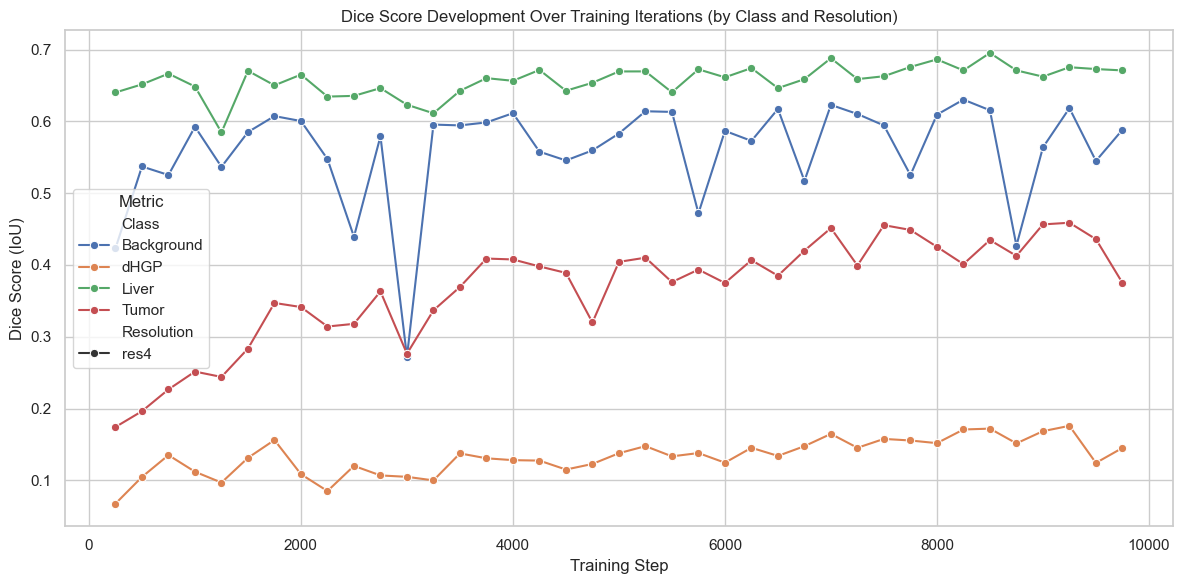

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
# Use lineplot:
# x: The chronological axis ('Step')
# y: The value ('Value')
# hue: The metric you want different lines for (e.g., 'Class')
# style (optional): Can be used to differentiate resolutions if desired
sns.lineplot(
    data=df_dice,
    x='Step',
    y='Value',
    hue='Class',          # Differentiate lines by class (Background, dHGP, etc.)
    style='Resolution',   # Differentiate line styles by resolution (res4, res5, etc.)
    marker='o',           # Add markers for clarity
    dashes=False
)

plt.title('Dice Score Development Over Training Iterations (by Class and Resolution)')
plt.xlabel('Training Step')
plt.ylabel('Dice Score (IoU)')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [9]:

LOG_DIR = 'D:/tfm_data/hpc_results/20251119_162604_split1_100epochs_16bs/loss_supervised_focal'
ea = EventAccumulator(LOG_DIR)
ea.Reload()
ea.Tags()
# ea.Scalars()

{'images': [],
 'audio': [],
 'histograms': [],
 'scalars': ['loss/supervised'],
 'distributions': [],
 'tensors': [],
 'graph': False,
 'meta_graph': False,
 'run_metadata': []}

In [20]:
def get_training_loss_components(logdir):
    if not os.path.isdir(logdir):
        raise ModuleNotFoundError()
    else:
        results = []
        loss_types = ["dice", "focal"]
        dice_dir = os.path.join(logdir, "loss_supervised_dice")
        focal_dir = os.path.join(logdir, "loss_supervised_focal")
        loss_dirs = [dice_dir, focal_dir]
        for idx, loss_dir in enumerate(loss_dirs):
            ea = EventAccumulator(loss_dir)
            ea.Reload()
            print(ea.Tags())
            events = ea.Scalars(f"loss/supervised")
            results.extend([{"type": loss_types[idx],"value": event.value, "step": step} for step,event in enumerate(events)])
        return results

df_loss = pd.DataFrame(get_training_loss_components("D:/tfm_data/hpc_results/20251119_162604_split1_100epochs_16bs"))

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['loss/supervised'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}
{'images': [], 'audio': [], 'histograms': [], 'scalars': ['loss/supervised'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


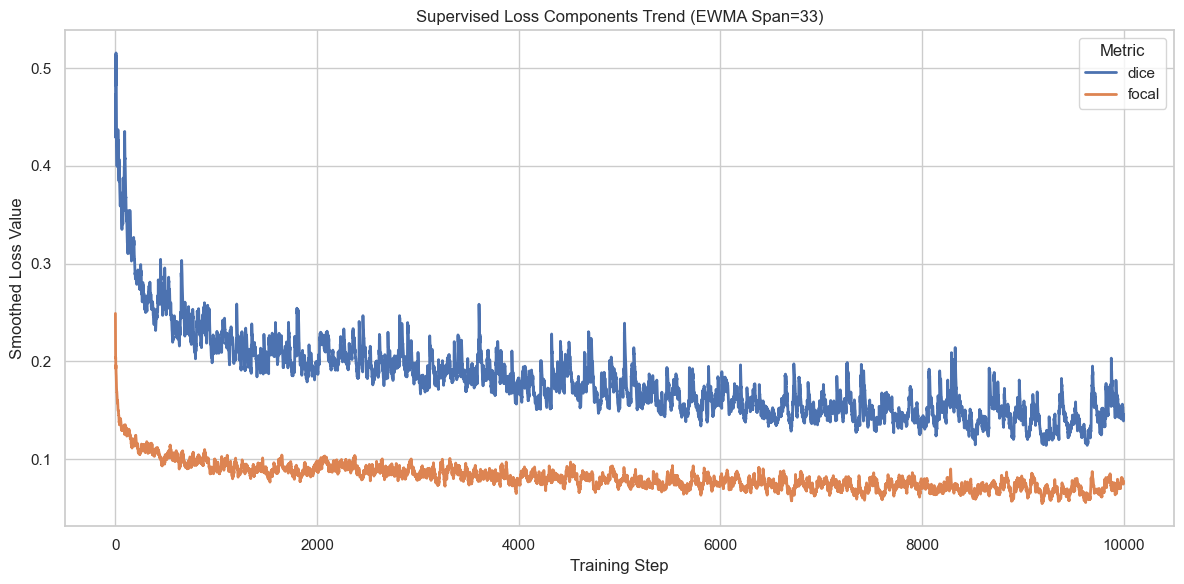

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
# 1. Separate the data by metric type
df_dice = df_loss[df_loss['type'] == 'dice'].copy()
df_focal = df_loss[df_loss['type'] == 'focal'].copy()

# Define a smoothing factor (alpha=0.01 is light, alpha=0.1 is heavier)
# Or use a window size (span=20 means roughly a 20-step average)
SMOOTHING_SPAN = 33

# 2. Apply Exponential Moving Average (EWMA)
df_dice['smoothed_value'] = df_dice['value'].ewm(span=SMOOTHING_SPAN).mean()
df_focal['smoothed_value'] = df_focal['value'].ewm(span=SMOOTHING_SPAN).mean()

# 3. Combine the smoothed data back
df_smoothed = pd.concat([df_dice, df_focal])

# 4. Plot the smoothed data
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_smoothed,
    x='step',
    y='smoothed_value',  # Plot the new smoothed column
    hue='type',
    linewidth=2
)

plt.title(f'Supervised Loss Components Trend (EWMA Span={SMOOTHING_SPAN})')
plt.xlabel('Training Step')
plt.ylabel('Smoothed Loss Value')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

## Development of Mean of Adaptive Normal

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams["font.family"] = "serif"
plt.rcParams['axes.titlesize'] = 16 
plt.rcParams['axes.labelsize'] = 12 

default_bar_color = "#008b8b"
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=[default_bar_color])
print("Global plot defaults (serif font, color #008b8b) have been set.")

import matplotlib.font_manager as fm

print(fm.findfont(fm.FontProperties(family='serif')))

Global plot defaults (serif font, color #008b8b) have been set.
C:\Users\nicol\master_thesis\code\.venv\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\DejaVuSerif.ttf


In [1]:
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os
import numpy as np

LOG_DIRS = [
    'D:/tfm_data/hpc_results/20251218_195105_split1_100epochs_6bs',
    'D:/tfm_data/hpc_results/20251218_210308_split2_100epochs_6bs',
    ]

mean_values_per_split = []
for split_dir in LOG_DIRS:
    ea = EventAccumulator(
        split_dir,
        size_guidance={
            "scalars": 0,
        })
    ea.Reload()
    events = ea.Scalars("params/mean_normal")
    mean_values = np.array([event.value for event in events])
    mean_values_per_split.append(mean_values)

np.savez("C:/users/nicol/master_thesis/code/analysis/mean_split1.npz", values = mean_values_per_split[0])

fig, axes = plt.subplots(1,len(mean_values_per_split),figsize = (20,5))
for idx,ax in enumerate(axes.flatten()):
    ax.plot(np.arange(len(mean_values_per_split[idx])), mean_values_per_split[idx])
    ax.set_title(f'Mean over Time Split {idx+1}', fontsize = 12)
    ax.set_xlabel('Iteration', fontsize = 10)
    ax.set_ylabel('Normal Mean Value', fontsize = 10)

NameError: name 'plt' is not defined

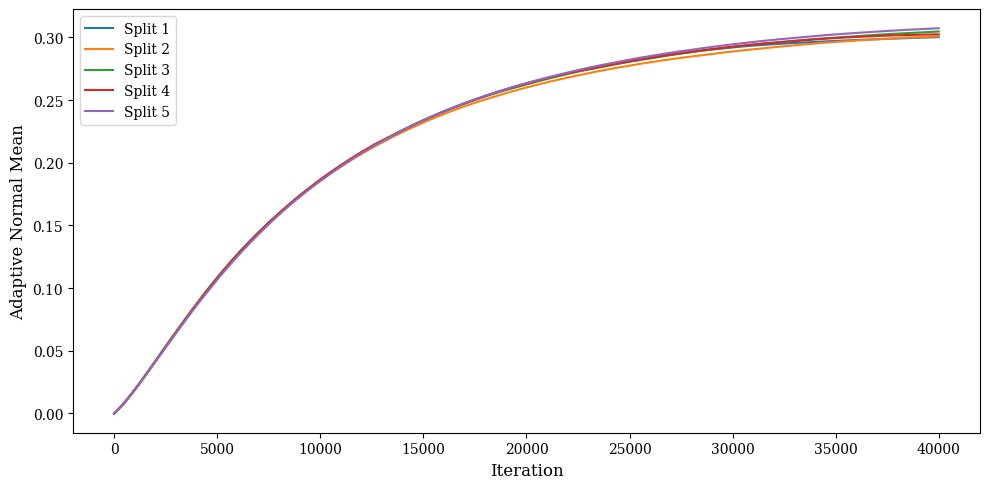

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

LOG_DIRS = [
    'D:/tfm_data/hpc_results/20251218_195105_split1_100epochs_6bs',
    'D:/tfm_data/hpc_results/20251218_210308_split2_100epochs_6bs',
    'D:/tfm_data/hpc_results/20251218_222812_split3_100epochs_6bs',
    'D:/tfm_data/hpc_results/20251218_223124_split4_100epochs_6bs',
    'D:/tfm_data/hpc_results/20251218_224614_split5_100epochs_6bs'
]

colors = plt.cm.tab10.colors  # distinct, colorblind-friendly

plt.figure(figsize=(10, 5))

for idx, split_dir in enumerate(LOG_DIRS):
    ea = EventAccumulator(
        split_dir,
        size_guidance={"scalars": 0}
    )
    ea.Reload()

    events = ea.Scalars("params/mean_normal")
    mean_values = np.array([event.value for event in events])

    plt.plot(
        np.arange(len(mean_values)),
        mean_values,
        color=colors[idx],
        label=f"Split {idx + 1}"
    )

plt.xlabel("Iteration")
plt.ylabel("Adaptive Normal Mean")
# plt.title("Adaptive Mean Value over Time per Split")
plt.legend()
plt.tight_layout()
plt.show()


## Simulate Class Balance

In [ ]:
import os
import numpy as np
os.chdir("C:/users/nicol/master_thesis")
from src.utils.dataset_unlabeled import LMDBTorchDatasetUnlabeled, HardnessNormalBatchSampler

ds = LMDBTorchDatasetUnlabeled("D:/tfm_data/preprocessed/dataset_unlabeled_lvl4")
from torch.utils.data import DataLoader

sampler = HardnessNormalBatchSampler(dataset=ds, batch_size=16, threshold_hardness=0, mean_hardness=0.0, std_hardness=0.18)
dl = DataLoader(ds,batch_sampler=sampler)


mean_values = np.load("C:/Users/nicol/master_thesis/code/src/config/mean_split1.npz")["values"]

for val in mean_values:
    sampler.update_eval(val)